In [2]:
# imports needed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/CarSales_Mini.csv")

df.head() # first 5 rows of dataset

,city,bed,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,engine_cylinders,engine_displacement,engine_type,...,savings_amount,seller_rating,theft_title,torque,transmission_display,vehicle_damage_category,wheel_system_display,wheelbase,width,year
0,Houston,NaN,SUV / Crossover,12.0,NaN,117,77074,V8,5700.0,V8,...,0,4.035088,NaN,"403 lb-ft @ 3,600 RPM",Automatic,NaN,All-Wheel Drive,112.2 in,78 in,2020
1,Cincinnati,NaN,SUV / Crossover,17.0,NaN,73,45255,V6,3500.0,V6,...,109,4.552632,False,"253 lb-ft @ 4,800 RPM",5-Speed Automatic,NaN,Four-Wheel Drive,109.2 in,78.5 in,2013
2,Tucson,NaN,SUV / Crossover,20.0,NaN,35,85712,I4,2400.0,I4,...,675,4.000000,False,"172 lb-ft @ 4,900 RPM",6-Speed Automatic,NaN,Front-Wheel Drive,106.6 in,72.8 in,2013
3,Scottsdale,NaN,SUV / Crossover,17.0,NaN,92,85257,V6,3500.0,V6,...,358,4.132075,False,"255 lb-ft @ 4,000 RPM",6-Speed Automatic,NaN,Front-Wheel Drive,112.8 in,90.2 in,2017
4,Denver,NaN,Pickup Truck,18.0,NaN,18,80123,V6,3500.0,V6,...,0,4.268293,NaN,"400 lb-ft @ 4,500 RPM",Automatic,NaN,Four-Wheel Drive,145 in,96.8 in,2020


## 1. Dataset Structure and Data Quality

The dataset contains 219,762 vehicle records and 45 columns. Each row represents a vehicle listing, while the columns contain vehicle characteristics, seller information, and listing-related attributes.

In [3]:
df.shape # 219762 cars (rows) and 45 features (columns)

(219762, 45)

In [4]:
df.info() # displays summary of dataset (column names, data types, non-null counts, memory usage)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219762 entries, 0 to 219761
Data columns (total 45 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   city                     219762 non-null  object 
 1   bed                      1262 non-null    object 
 2   body_type                219112 non-null  object 
 3   city_fuel_economy        194022 non-null  float64
 4   combine_fuel_economy     0 non-null       float64
 5   daysonmarket             219762 non-null  int64  
 6   dealer_zip               219762 non-null  int64  
 7   engine_cylinders         219762 non-null  object 
 8   engine_displacement      212947 non-null  float64
 9   engine_type              219762 non-null  object 
 10  frame_damaged            122479 non-null  object 
 11  franchise_dealer         219762 non-null  bool   
 12  front_legroom            214454 non-null  object 
 13  fuel_tank_volume         214454 non-null  object 
 14  fuel

In [5]:
missing = pd.DataFrame({ # creates new table to summarize missing values
    "Missing_Count": df.isnull().sum(), # counts the number of missing values in each column
    "Missing_Percent": (df.isnull().sum() / len(df) * 100).round(2) # calcs percentage of values missing in each column
})

missing.sort_values("Missing_Percent", ascending=False) # sort table from highest to lowest percentage

,Missing_Count,Missing_Percent
combine_fuel_economy,219762,100.00
vehicle_damage_category,219762,100.00
bed,218500,99.43
owner_count,103592,47.14
frame_damaged,97283,44.27
theft_title,97283,44.27
has_accidents,97283,44.27
salvage,97283,44.27
torque,31219,14.21
city_fuel_economy,25740,11.71


### Missing Value Findings

Missingness varies substantially across the dataset.

- `combine_fuel_economy` and `vehicle_damage_category` are entirely missing (100%) and therefore contain no usable information in their current form. These columns should be flagged for removal during preprocessing.
- `bed` is 99.43% missing and is unlikely to provide enough information to be useful without further investigation.
- `owner_count` is missing 47.14% of its values.
- `frame_damaged`, `theft_title`, `has_accidents`, and `salvage` are each missing 44.27% of their values. These features may still contain useful information, but their substantial missingness will need to be addressed during preprocessing.
- `torque` is missing 14.21% of its values, while `city_fuel_economy` and `highway_fuel_economy` are each missing 11.71%.
- Several other potentially useful vehicle characteristics, including `mileage`, `horsepower`, and vehicle dimensions, have smaller amounts of missing data.

These issues will be flagged for the preprocessing stage rather than modified during the exploratory analysis.

In [6]:
object_cols = df.select_dtypes(include="object").columns # select all columns stored as text/object data

for col in object_cols: # loop through each object column
    print(f"{col}: {df[col].nunique()} unique values") # print the column name and number of unique vals (using nunique method)

city: 30 unique values
bed: 3 unique values
body_type: 9 unique values
engine_cylinders: 21 unique values
engine_type: 21 unique values
frame_damaged: 2 unique values
front_legroom: 87 unique values
fuel_tank_volume: 161 unique values
fuel_type: 5 unique values
has_accidents: 2 unique values
height: 419 unique values
length: 706 unique values
listed_date: 923 unique values
listing_color: 13 unique values
main_picture_url: 188995 unique values
major_options: 44684 unique values
make: 48 unique values
maximum_seating: 12 unique values
model: 790 unique values
salvage: 2 unique values
theft_title: 2 unique values
torque: 1334 unique values
transmission_display: 22 unique values
wheel_system_display: 5 unique values
wheelbase: 411 unique values
width: 257 unique values


In [7]:
# this is just a list of text columns to look at more closely
cols_to_inspect = [
    "bed",
    "engine_cylinders",
    "engine_type",
    "front_legroom",
    "fuel_tank_volume",
    "height",
    "length",
    "maximum_seating",
    "torque",
    "transmission_display",
    "wheelbase",
    "width"
]

for col in cols_to_inspect: # loop through each of those columns
    print(f"\n{col}:") # print column name
    print(df[col].dropna().unique()[:20]) #remove missing values, finds unique values and shows first 20


bed:
['Short' 'Regular' 'Long']

engine_cylinders:
['V8' 'V6' 'I4' 'I3' 'V6 Flex Fuel Vehicle' 'V6 Diesel' 'V8 Diesel'
 'V8 Flex Fuel Vehicle' 'I6' 'I6 Diesel' 'I4 Hybrid' 'V8 Biodiesel' 'H4'
 'V6 Hybrid' 'I4 Diesel' 'V12' 'I4 Flex Fuel Vehicle' 'H6' 'I5' 'V10']

engine_type:
['V8' 'V6' 'I4' 'I3' 'V6 Flex Fuel Vehicle' 'V6 Diesel' 'V8 Diesel'
 'V8 Flex Fuel Vehicle' 'I6' 'I6 Diesel' 'I4 Hybrid' 'V8 Biodiesel' 'H4'
 'V6 Hybrid' 'I4 Diesel' 'V12' 'I4 Flex Fuel Vehicle' 'H6' 'I5' 'V10']

front_legroom:
['42.9 in' '41.4 in' '40.7 in' '43.9 in' '41.7 in' '40.3 in' '42.3 in'
 '41.2 in' '40.8 in' '40.9 in' '41 in' '41.1 in' '45.3 in' '42.4 in'
 '42.2 in' '44.1 in' '41.5 in' '42 in' '41.3 in' '40.5 in']

fuel_tank_volume:
['24.6 gal' '21 gal' '19 gal' '18.6 gal' '23 gal' '9 gal' '26 gal'
 '19.5 gal' '13.2 gal' '17.4 gal' '14.5 gal' '15.8 gal' '15.3 gal'
 '14.7 gal' '16.6 gal' '17.2 gal' '18.8 gal' '16.4 gal' '16 gal'
 '14.3 gal']

height:
['75.2 in' '72.7 in' '67 in' '70 in' '77.2 in' '58.4 i

In [8]:
print("engine_cylinders identical to engine_type:",
      df["engine_cylinders"].equals(df["engine_type"]))

print("\nMaximum seating value counts:")
print(df["maximum_seating"].value_counts(dropna=False))

engine_cylinders identical to engine_type: True

Maximum seating value counts:
maximum_seating
5 seats     144549
7 seats      24934
6 seats      18976
8 seats      14196
4 seats       6973
NaN           5308
2 seats       2318
3 seats       1525
15 seats       543
9 seats        285
12 seats       103
--              30
10 seats        22
Name: count, dtype: int64


### Initial Data Quality Findings

Several data quality and representation issues were identified:

- `combine_fuel_economy` and `vehicle_damage_category` contain 100% missing values and should be removed during preprocessing.
- `bed` contains 99.43% missing values and should be evaluated for removal due to its extremely limited coverage.
- `engine_cylinders` and `engine_type` are completely identical across all 219,762 records. One of these redundant features should be removed during preprocessing.
- Several numeric measurements are stored as text because their units are included in the values. These include `front_legroom`, `height`, `length`, `wheelbase`, and `width` (inches), as well as `fuel_tank_volume` (gallons). These should be converted to numeric values during preprocessing.
- `maximum_seating` is stored as text (e.g., `5 seats`) and contains 30 `"--"` placeholder values. The seating count should be converted to numeric form and `"--"` treated as missing during preprocessing.
- `torque` combines torque and RPM information in a single text field (e.g., `403 lb-ft @ 3,600 RPM`). This field may be parsed into separate numeric features during preprocessing.
- Several measurement columns contain `"--"` as a placeholder for missing or unavailable values. This occurs in `front_legroom` (1,539 records), `fuel_tank_volume` (42), `height` (29), `length` (29), `maximum_seating` (30), `wheelbase` (28), and `width` (29). These placeholders should be converted to missing values before numeric conversion during preprocessing.
- The dataset contains 3 exact duplicate rows. These duplicate records should be removed during preprocessing to prevent repeated observations from influencing the model.
- `mileage` contains one clearly implausible value of 99,999,988 miles. The next-highest mileage is 590,072 miles, suggesting that the 99,999,988 value is an isolated data error or placeholder rather than part of the normal mileage distribution. This record should be addressed during preprocessing.

In [9]:
placeholders = ["--", "N/A", "NA", "Unknown", "unknown", "None", "null", ""]

for col in object_cols:
    counts = df[col].astype(str).str.strip().value_counts()
    
    found = counts[counts.index.isin(placeholders)]
    
    if len(found) > 0:
        print(f"\n{col}:")
        print(found)


front_legroom:
front_legroom
--    1539
Name: count, dtype: int64

fuel_tank_volume:
fuel_tank_volume
--    42
Name: count, dtype: int64

height:
height
--    29
Name: count, dtype: int64

length:
length
--    29
Name: count, dtype: int64

maximum_seating:
maximum_seating
--    30
Name: count, dtype: int64

wheelbase:
wheelbase
--    28
Name: count, dtype: int64

width:
width
--    29
Name: count, dtype: int64


In [10]:
candidate_cols = [
    "listing_id",
    "main_picture_url",
    "combine_fuel_economy",
    "vehicle_damage_category"
]

for col in candidate_cols:
    print(f"{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Missing: {df[col].isna().mean() * 100:.2f}%")

listing_id:
  Unique values: 219759
  Missing: 0.00%
main_picture_url:
  Unique values: 188995
  Missing: 8.87%
combine_fuel_economy:
  Unique values: 0
  Missing: 100.00%
vehicle_damage_category:
  Unique values: 0
  Missing: 100.00%


### Features Likely to Be Unhelpful for Price Prediction

Several columns are unlikely to provide useful predictive information in their current form:

- `listing_id` is essentially a unique identifier, with 219,759 unique values across 219,762 records. It identifies listings rather than describing characteristics that should determine vehicle price.
- `main_picture_url` has 188,995 unique values and represents the location of a listing image rather than a directly useful tabular vehicle characteristic. It is unlikely to be useful in its current form.
- `combine_fuel_economy` contains 100% missing values and therefore provides no information for prediction.
- `vehicle_damage_category` also contains 100% missing values and provides no information for prediction.
- Because `engine_cylinders` and `engine_type` are identical across the entire dataset, retaining both would be redundant. One should be removed during preprocessing.

Other features such as geographic location and listing date will not be classified as useless at this stage because they may contain predictive information about regional or temporal differences in vehicle prices.

In [11]:
df.duplicated().sum()

np.int64(3)

In [12]:
df[df.duplicated(keep=False)].sort_values("listing_id")

,city,bed,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,engine_cylinders,engine_displacement,engine_type,...,savings_amount,seller_rating,theft_title,torque,transmission_display,vehicle_damage_category,wheel_system_display,wheelbase,width,year
105751,Columbus,NaN,SUV / Crossover,25.0,NaN,166,43230,I4,2500.0,I4,...,0,4.500000,NaN,"175 lb-ft @ 4,400 RPM",Continuously Variable Transmission,NaN,All-Wheel Drive,106.5 in,72.4 in,2020
187404,Columbus,NaN,SUV / Crossover,25.0,NaN,166,43230,I4,2500.0,I4,...,0,4.500000,NaN,"175 lb-ft @ 4,400 RPM",Continuously Variable Transmission,NaN,All-Wheel Drive,106.5 in,72.4 in,2020
185199,Columbus,NaN,Sedan,28.0,NaN,46,43230,I4,2500.0,I4,...,0,4.500000,NaN,"180 lb-ft @ 3,600 RPM",Continuously Variable Transmission,NaN,Front-Wheel Drive,111.2 in,72.9 in,2020
75658,Columbus,NaN,Sedan,28.0,NaN,46,43230,I4,2500.0,I4,...,0,4.500000,NaN,"180 lb-ft @ 3,600 RPM",Continuously Variable Transmission,NaN,Front-Wheel Drive,111.2 in,72.9 in,2020
153372,Columbus,NaN,SUV / Crossover,21.0,NaN,26,43229,I4,2000.0,I4,...,0,4.578947,NaN,"280 lb-ft @ 3,000 RPM",8-Speed Automatic,NaN,All-Wheel Drive,112.2 in,85.8 in,2020
12217,Columbus,NaN,SUV / Crossover,21.0,NaN,26,43229,I4,2000.0,I4,...,0,4.578947,NaN,"280 lb-ft @ 3,000 RPM",8-Speed Automatic,NaN,All-Wheel Drive,112.2 in,85.8 in,2020


In [13]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_cols

numeric_eda_cols = [
    "price",
    "mileage",
    "year",
    "horsepower",
    "engine_displacement",
    "city_fuel_economy",
    "highway_fuel_economy",
    "daysonmarket",
    "owner_count",
    "savings_amount",
    "seller_rating"
]

df[numeric_eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,219762.0,29179.538813,18522.858907,386.9,17990.000000,25260.00000,36800.000000,1100000.0
mileage,207925.0,31021.258204,223167.440800,0.0,8.000000,14341.00000,43049.000000,99999988.0
year,219762.0,2017.990854,3.166185,1981.0,2017.000000,2019.00000,2020.000000,2021.0
horsepower,212947.0,247.503867,90.411723,67.0,175.000000,243.00000,300.000000,797.0
engine_displacement,212947.0,2912.693769,1305.968058,900.0,2000.000000,2500.00000,3500.000000,8400.0
city_fuel_economy,194022.0,22.444027,6.186447,8.0,18.000000,22.00000,26.000000,81.0
highway_fuel_economy,194022.0,29.500886,6.166271,11.0,25.000000,29.00000,33.000000,86.0
daysonmarket,219762.0,72.512190,101.735886,0.0,14.000000,35.00000,78.000000,2416.0
owner_count,116170.0,1.504459,0.880386,1.0,1.000000,1.00000,2.000000,13.0
savings_amount,219762.0,597.883374,1103.637370,0.0,0.000000,1.00000,886.000000,130021.0


## 2. Univariate Distributions

### Numeric Summary Findings

The descriptive statistics reveal several notable characteristics and potential outliers:

- `price`, the prediction target, has a median of 25,260 USD and a mean of approximately 29,180 USD. The higher mean and maximum value of 1.1 million USD suggest a right-skewed distribution with high-price outliers.
- `mileage` contains an extreme maximum value of 99,999,988 miles, compared with a median of 14,341 miles and 75th percentile of 43,049 miles. This value is implausible for a vehicle and likely represents erroneous or placeholder data that should be investigated and addressed during preprocessing.
- `daysonmarket` has a median of 35 days but a mean of approximately 73 days and a maximum of 2,416 days, suggesting substantial right skew and extreme observations.
- `savings_amount` has a median of only 1 USD but a maximum of 130,021 USD, indicating a highly right-skewed distribution with potential outliers.
- `horsepower`, `engine_displacement`, and fuel economy measures have much narrower ranges, although their extreme values should still be evaluated.
- `owner_count` ranges from 1 to 13 owners, while `seller_rating` is bounded between 1 and 5 as expected.

In [14]:
df["mileage"].nlargest(20)

39993     99999988.0
68570       590072.0
50016       397322.0
194856      391398.0
58114       379647.0
199108      356951.0
40977       354628.0
79692       351123.0
108223      346927.0
168956      345409.0
78578       343156.0
115098      342769.0
100995      341472.0
20034       334500.0
15230       326000.0
11777       323920.0
25621       318213.0
51622       315891.0
102990      314268.0
201824      313550.0
Name: mileage, dtype: float64

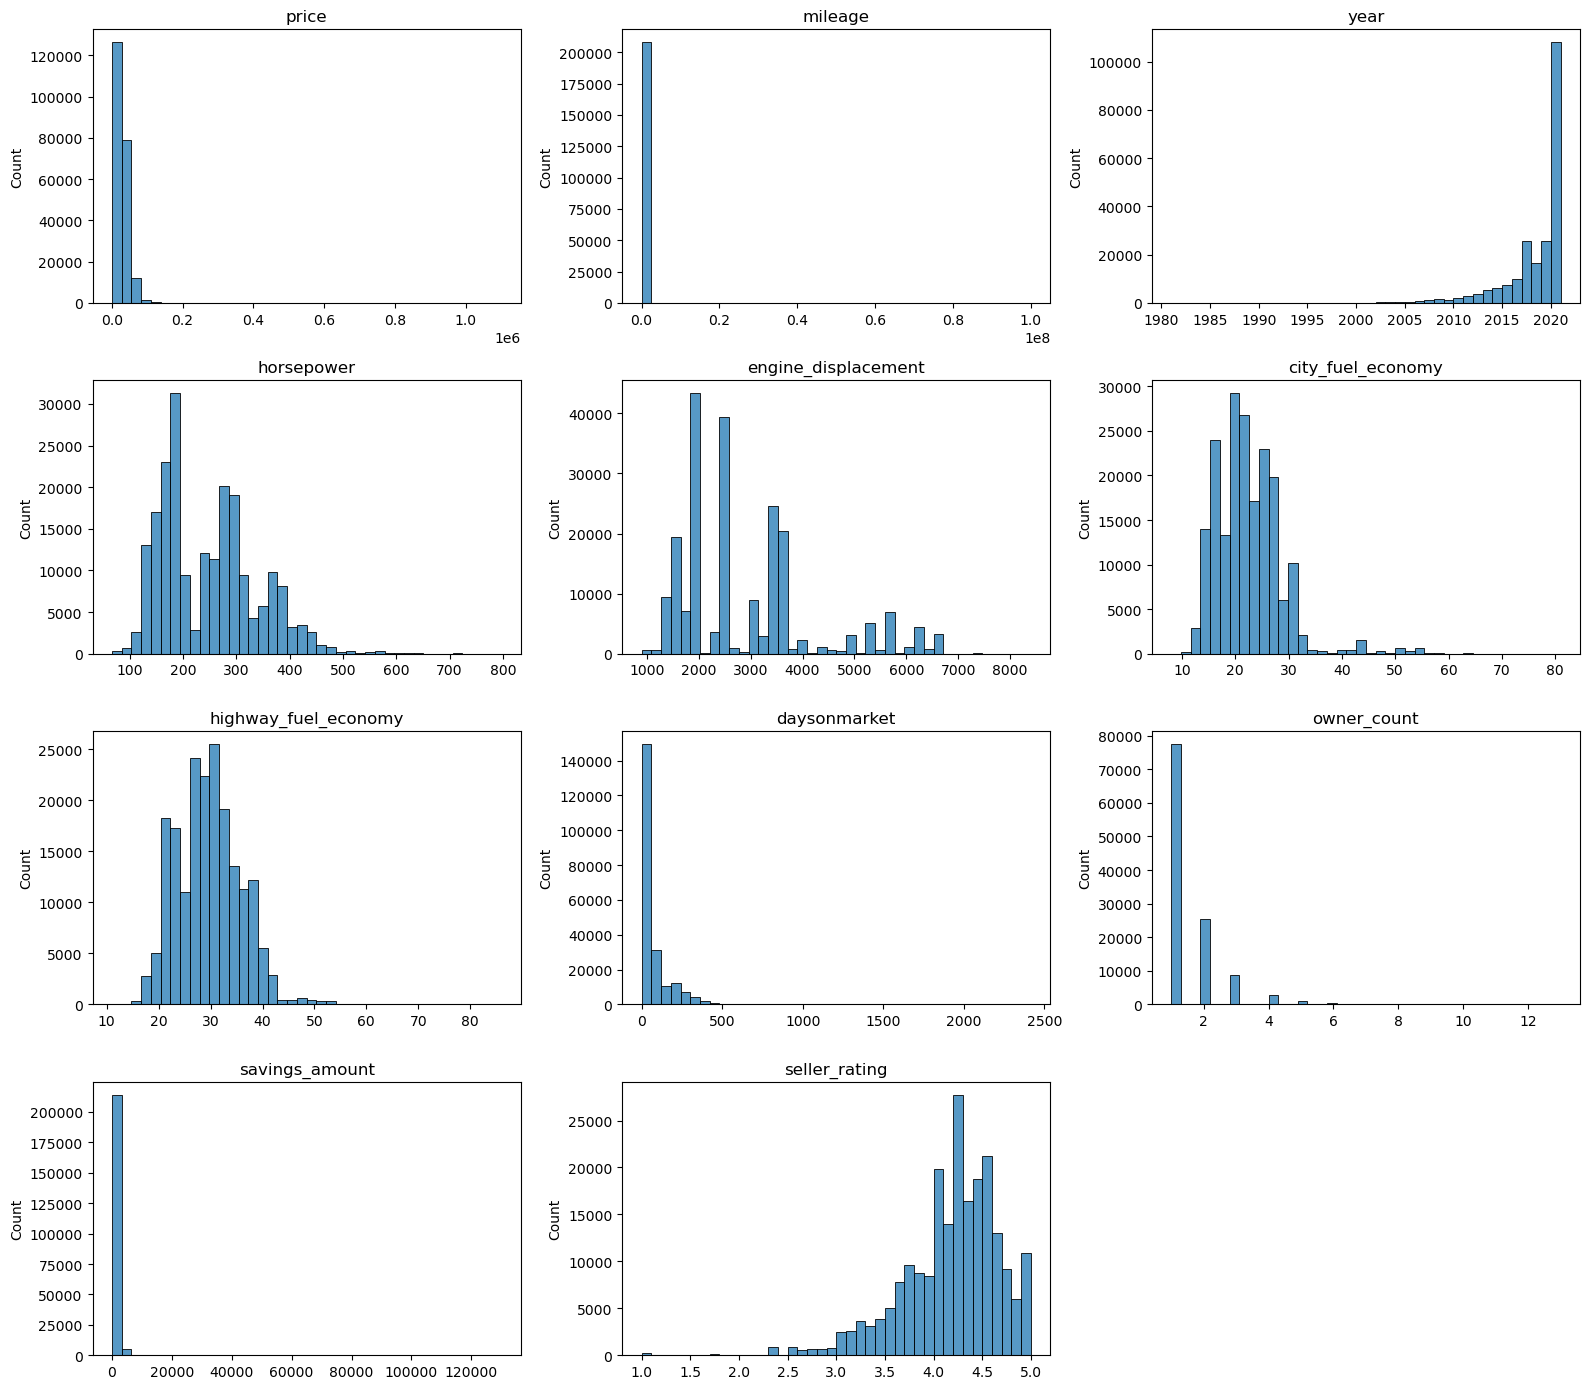

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_eda_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# remove unused subplot
for j in range(len(numeric_eda_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Numeric Distribution Findings

The histograms reveal several important distributional patterns:

- `price` is strongly right-skewed. Most vehicles are concentrated in the lower portion of the price range, while a small number of extremely expensive listings create a long right tail.
- `mileage` is severely distorted by the previously identified 99,999,988-mile observation. This single implausible value compresses nearly the entire legitimate mileage distribution near zero, further supporting its treatment as a data-quality issue during preprocessing.
- `year` is heavily concentrated among recent model years, particularly vehicles from the late 2010s through 2021. Relatively few older vehicles appear in the dataset.
- `horsepower` and `engine_displacement` show multiple clusters, consistent with vehicles having common standardized engine configurations. Both also exhibit right tails toward higher-performance vehicles.
- `city_fuel_economy` and `highway_fuel_economy` are concentrated around their central ranges but contain smaller right tails representing unusually fuel-efficient vehicles.
- `daysonmarket` is strongly right-skewed. Most listings spend relatively little time on the market, while a small number remain listed for extremely long periods.
- `owner_count` is concentrated at one or two previous owners, with progressively fewer vehicles having larger numbers of previous owners.
- `savings_amount` is extremely right-skewed, with most observations near zero and a small number of very large values.
- `seller_rating` is concentrated toward the upper end of its 1–5 scale, indicating that most sellers in the dataset have relatively high ratings.

Overall, several numeric variables contain substantial skew and extreme observations. These characteristics should be considered during preprocessing and model selection.

In [16]:
outlier_results = []

for col in numeric_eda_cols:
    data = df[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    outlier_results.append({
        "Column": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percent": round(len(outliers) / len(data) * 100, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2)
    })

pd.DataFrame(outlier_results).sort_values(
    "Outlier_Percent", ascending=False
)

,Column,Outlier_Count,Outlier_Percent,Lower_Bound,Upper_Bound
7,daysonmarket,30238,13.76,-82.00,174.00
1,mileage,14722,7.08,-64553.50,107610.50
2,year,15231,6.93,2012.50,2024.50
9,savings_amount,15239,6.93,-1329.00,2215.00
4,engine_displacement,9864,4.63,-250.00,5750.00
8,owner_count,4407,3.79,-0.50,3.50
10,seller_rating,7371,3.39,3.08,5.36
0,price,7176,3.27,-10225.00,65015.00
5,city_fuel_economy,4548,2.34,6.00,38.00
6,highway_fuel_economy,2077,1.07,13.00,45.00


### Outlier Findings

Using the 1.5 × IQR rule, several numeric variables contain substantial numbers of statistical outliers.

- `daysonmarket` has the largest proportion of outliers at 13.76%, with values above 174 days considered outliers under the IQR rule.
- `mileage` has 7.08% of observations flagged as outliers. Most may represent legitimate high-mileage vehicles, although the previously identified value of 99,999,988 miles is clearly implausible and should be treated as a data-quality issue.
- `savings_amount` also has 6.93% of observations flagged, consistent with its strongly right-skewed distribution.
- `price` has 7,176 observations (3.27%) outside the IQR bounds, primarily representing unusually expensive vehicles.
- Other variables including `engine_displacement`, `owner_count`, and fuel economy measures also contain statistical outliers.

Importantly, statistical outliers are not necessarily data errors. For example, expensive vehicles, older model years, high-horsepower vehicles, and high-mileage vehicles may be legitimate observations. Outlier treatment during preprocessing should therefore distinguish implausible values from valid but uncommon vehicles.

In [17]:
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns

cardinality = pd.DataFrame({ # cardinality - number of unique items in a dataset
    "Unique_Values": df[categorical_cols].nunique(),
    "Missing_Count": df[categorical_cols].isnull().sum()
})

cardinality.sort_values("Unique_Values", ascending=False)

,Unique_Values,Missing_Count
main_picture_url,188995,19496
major_options,44684,0
torque,1334,31219
listed_date,923,0
model,790,0
length,706,5308
height,419,5308
wheelbase,411,5308
width,257,5308
fuel_tank_volume,161,5308


### Categorical Cardinality Findings

Cardinality refers to the number of unique values within a categorical feature.

Several features have notably high cardinality:

- `main_picture_url` has 188,995 unique values, reinforcing that it behaves more like a listing-specific identifier than a useful categorical predictor.
- `major_options` has 44,684 unique values because vehicles can have many different combinations of options. This feature will require special handling rather than straightforward categorical encoding.
- `model` contains 790 unique vehicle models. Although this is high-cardinality, vehicle model is likely to contain important information for predicting price and should not automatically be removed.
- `listed_date` contains 923 unique values but represents dates rather than a traditional categorical variable. It should be converted to a datetime representation during preprocessing.
- `make` contains 48 unique manufacturers and `city` contains 30 unique locations, representing moderate-cardinality categorical features.

Several other columns appear high-cardinality because numeric measurements are currently stored as strings. For example, `length`, `height`, `wheelbase`, `width`, and `fuel_tank_volume` should ultimately be treated as numeric rather than high-cardinality categorical features.

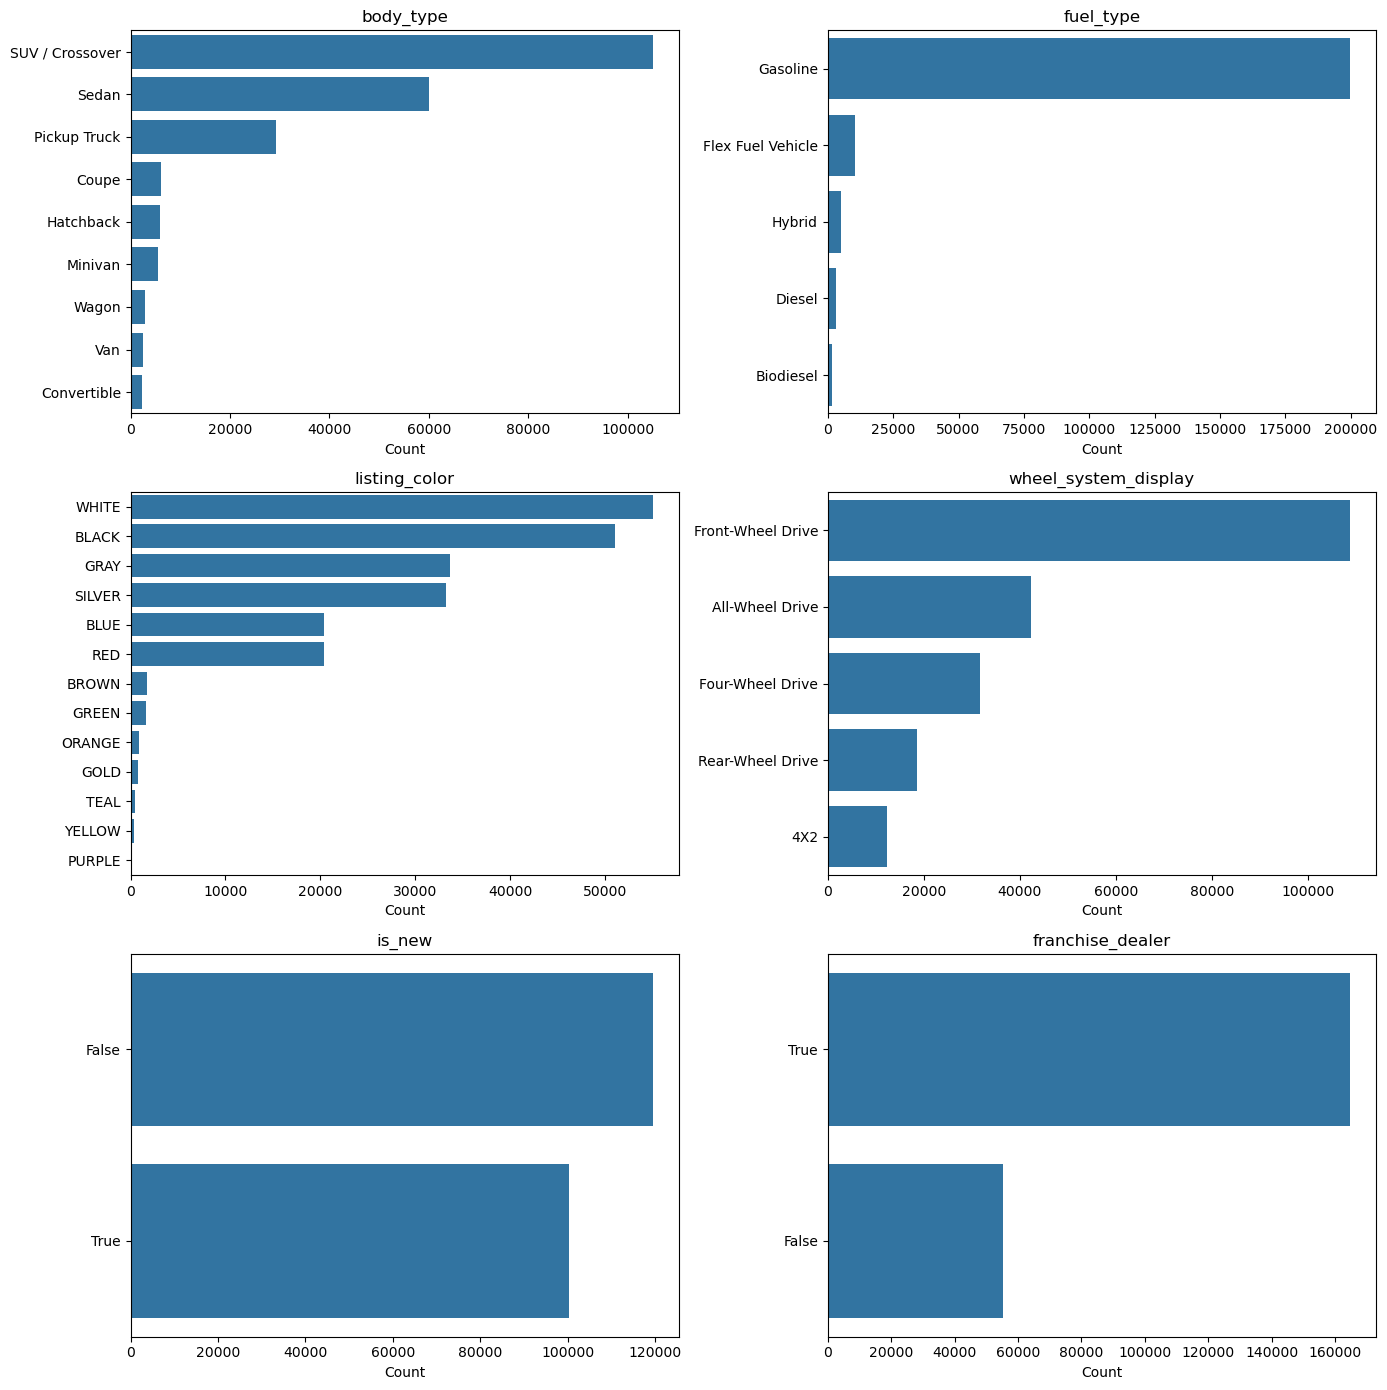

In [18]:
plot_cols = [
    "body_type",
    "fuel_type",
    "listing_color",
    "wheel_system_display",
    "is_new",
    "franchise_dealer"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    order = df[col].value_counts().index
    
    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[i]
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [19]:
for col in plot_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


body_type:
body_type
SUV / Crossover    104984
Sedan               59957
Pickup Truck        29222
Coupe                6070
Hatchback            5873
Minivan              5470
Wagon                2811
Van                  2503
Convertible          2222
NaN                   650
Name: count, dtype: int64

fuel_type:
fuel_type
Gasoline             199557
Flex Fuel Vehicle     10535
Hybrid                 4920
Diesel                 3128
Biodiesel              1622
Name: count, dtype: int64

listing_color:
listing_color
WHITE     54997
BLACK     51087
GRAY      33623
SILVER    33264
BLUE      20386
RED       20337
BROWN      1772
GREEN      1666
ORANGE      889
GOLD        757
TEAL        436
YELLOW      410
PURPLE      138
Name: count, dtype: int64

wheel_system_display:
wheel_system_display
Front-Wheel Drive    108730
All-Wheel Drive       42337
Four-Wheel Drive      31679
Rear-Wheel Drive      18515
4X2                   12375
NaN                    6126
Name: count, dtype: int64

i

### Categorical Distribution Findings

The categorical distributions reveal several notable patterns:

- `body_type` is dominated by SUVs/Crossovers (104,984 listings), followed by Sedans (59,957) and Pickup Trucks (29,222). Other body styles such as Coupes, Hatchbacks, Minivans, Wagons, Vans, and Convertibles are substantially less common.
- `fuel_type` is highly imbalanced. Gasoline vehicles account for 199,557 of the 219,762 listings, while Flex Fuel, Hybrid, Diesel, and Biodiesel vehicles make up much smaller portions of the dataset.
- `listing_color` is concentrated among a few common colors. White, black, gray, and silver are the most frequent, while colors such as purple, yellow, teal, and gold are relatively rare.
- `wheel_system_display` is dominated by Front-Wheel Drive vehicles (108,730 listings), followed by All-Wheel Drive and Four-Wheel Drive vehicles.
- The dataset contains both new and used vehicles, with used vehicles (119,432) slightly more common than new vehicles (100,330).
- Franchise dealers account for 164,597 listings, approximately three-quarters of the dataset, indicating substantial imbalance in this feature.

These imbalances are important because some categories are represented by far more observations than others, which may affect subsequent modeling and interpretation.

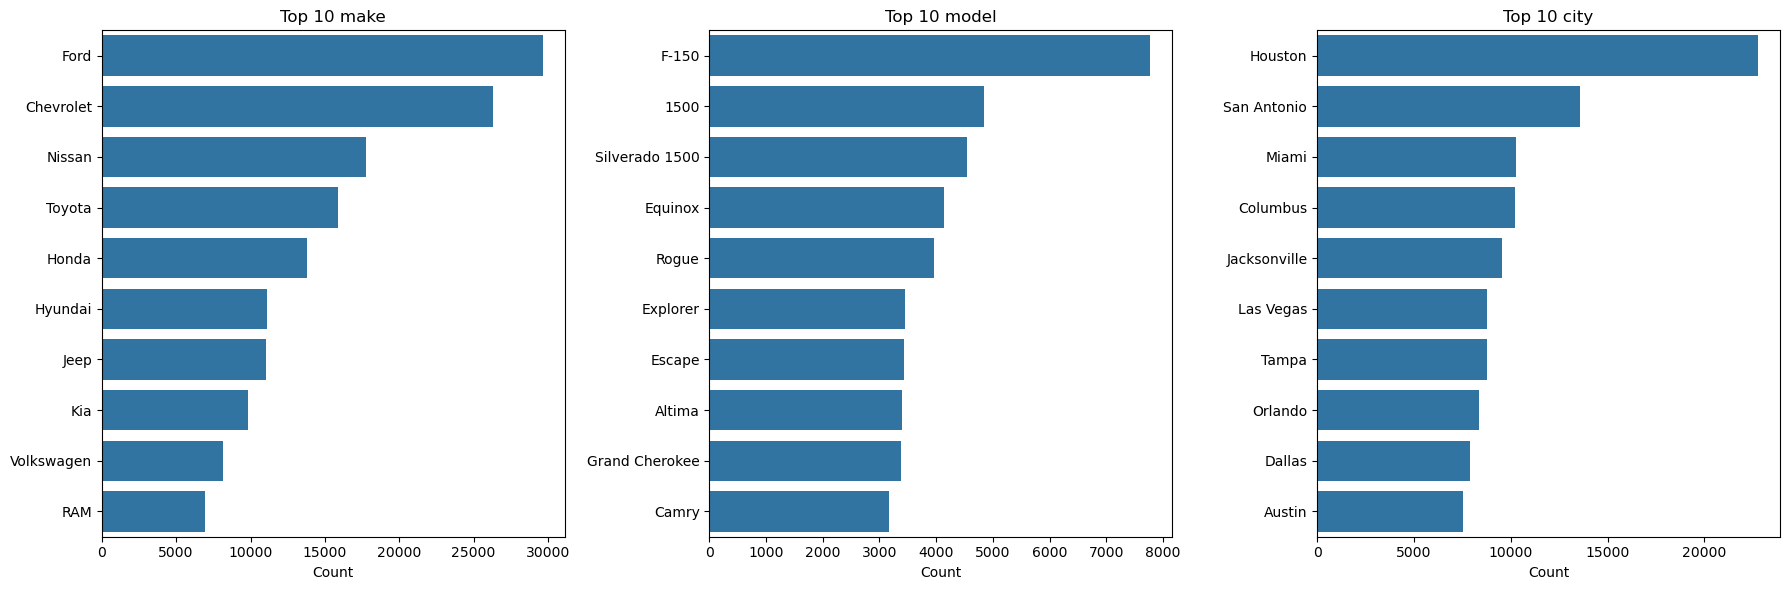

In [20]:
top_cols = ["make", "model", "city"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(top_cols):
    top_10 = df[col].value_counts().head(10)
    
    sns.barplot(
        x=top_10.values,
        y=top_10.index,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Top 10 {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### High-Cardinality Feature Frequencies

Among vehicle manufacturers, Ford and Chevrolet are the most frequently represented makes in the dataset. The most common individual model is the Ford F-150, followed by the RAM 1500 and Chevrolet Silverado 1500. Several SUVs also appear among the ten most common models.

The geographic distribution is also uneven. Houston contains substantially more listings than any other city, followed by San Antonio. This indicates that the dataset is not evenly distributed across its 30 represented cities.

Although `model` is a high-cardinality feature with 790 unique values, the frequency distribution suggests that certain models occur frequently enough to provide potentially useful predictive information.

## 3. Bivariate Relationships

In [21]:
correlation_cols = [
    "price",
    "mileage",
    "year",
    "horsepower",
    "engine_displacement",
    "city_fuel_economy",
    "highway_fuel_economy",
    "daysonmarket",
    "owner_count",
    "savings_amount",
    "seller_rating"
]

price_correlations = (
    df[correlation_cols]
    .corr()["price"]
    .drop("price")
    .sort_values(ascending=False)
)

price_correlations

horsepower              0.617181
year                    0.397810
engine_displacement     0.380778
seller_rating           0.091820
daysonmarket            0.076284
savings_amount          0.016778
mileage                -0.080849
owner_count            -0.217092
city_fuel_economy      -0.308326
highway_fuel_economy   -0.385782
Name: price, dtype: float64

### Numeric Relationships with Price

Among the numeric features, `horsepower` has the strongest linear relationship with price, with a correlation of 0.617. This indicates that higher-horsepower vehicles tend to have higher prices.

`year` (0.398) and `engine_displacement` (0.381) also have moderate positive correlations with price, suggesting that newer vehicles and vehicles with larger engines tend to be more expensive.

Fuel economy shows moderate negative relationships with price. `highway_fuel_economy` has a correlation of -0.386 and `city_fuel_economy` has a correlation of -0.308. This may reflect differences between smaller, fuel-efficient vehicles and larger or higher-performance vehicles rather than fuel economy directly causing lower prices.

`owner_count` has a negative correlation of -0.217, indicating that vehicles with more previous owners tend to have lower prices.

The remaining numeric features show relatively weak linear relationships with price. These correlations describe association rather than causation and may not capture nonlinear relationships or interactions between vehicle characteristics.

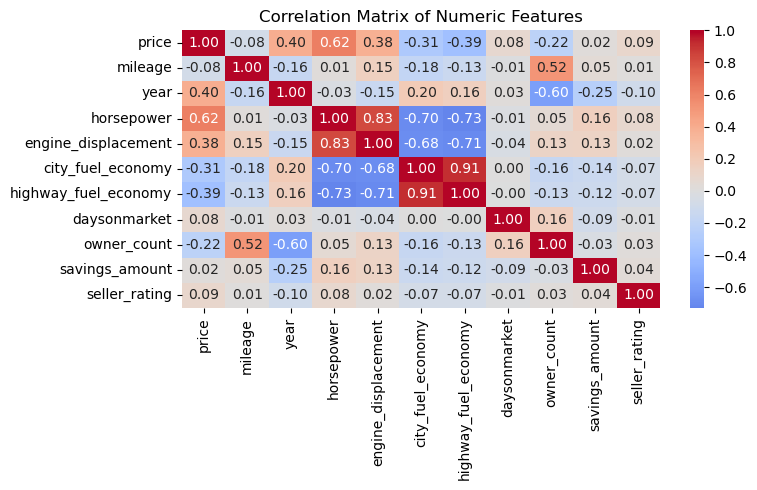

In [22]:
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

### Correlations Among Predictive Features

Several features associated with vehicle price are also strongly correlated with one another.

The strongest relationship is between `city_fuel_economy` and `highway_fuel_economy` (0.91), indicating that these two variables contain highly overlapping information.

`horsepower` and `engine_displacement` are also strongly positively correlated (0.83). Both are negatively correlated with fuel economy: horsepower has correlations of -0.70 with city fuel economy and -0.73 with highway fuel economy, while engine displacement has correlations of -0.68 and -0.71, respectively.

Together, these relationships suggest an underlying performance-related pattern: vehicles with larger engines generally produce more horsepower while achieving lower fuel economy. Because these predictors contain overlapping information, potential multicollinearity should be considered during modeling.

`year` and `owner_count` have a moderately strong negative correlation (-0.60), suggesting that newer vehicles tend to have fewer previous owners. `mileage` and `owner_count` are positively correlated (0.52), indicating that higher-mileage vehicles also tend to have had more owners.

In [23]:
for col in ["is_new", "body_type", "fuel_type"]:
    print(f"\nMedian price by {col}:")
    
    display(
        df.groupby(col)["price"]
          .agg(["count", "median", "mean"])
          .sort_values("median", ascending=False)
          .round(2)
    )


Median price by is_new:


,count,median,mean
is_new,,,
True,100330,31999.0,36440.00
False,119432,19500.0,23080.32



Median price by body_type:


,count,median,mean
body_type,,,
Pickup Truck,29222,39700.0,40969.88
Convertible,2222,30949.0,46138.74
Coupe,6070,28197.0,39126.71
SUV / Crossover,104984,26615.0,30220.66
Van,2503,26570.0,28620.20
Minivan,5470,23573.5,24681.43
Sedan,59957,19492.0,22072.22
Hatchback,5873,15995.0,16764.75
Wagon,2811,14991.0,18964.42



Median price by fuel_type:


,count,median,mean
fuel_type,,,
Biodiesel,1622,59260.5,58606.06
Diesel,3128,46962.0,41853.30
Flex Fuel Vehicle,10535,26000.0,26916.31
Hybrid,4920,25265.0,25688.80
Gasoline,199557,24998.0,28947.25


### Categorical Relationships with Price

Several categorical vehicle characteristics show substantial differences in price.

- New vehicles have a median price of 31,999 USD compared with 19,500 USD for used vehicles, indicating that `is_new` is likely an important predictor of price.
- Vehicle body type is also associated with price. Pickup trucks have the highest median price (39,700 USD), while sedans (19,492 USD), hatchbacks (15,995 USD), and wagons (14,991 USD) have substantially lower median prices.
- Convertibles and coupes have means substantially higher than their medians, suggesting that expensive luxury or performance vehicles create right-skewed price distributions within these categories.
- Fuel type also shows substantial price differences. Biodiesel and diesel vehicles have median prices of 59,260.50 USD and 46,962 USD, respectively, considerably higher than gasoline, hybrid, and flex-fuel vehicles. However, diesel and biodiesel vehicles represent much smaller portions of the dataset, so these differences should be interpreted in the context of vehicle type and sample size.

Overall, the results indicate that categorical characteristics such as new/used status, body type, and fuel type may provide important predictive information beyond the numeric correlations examined previously.

In [24]:
make_price = (
    df.groupby("make")["price"]
      .agg(["count", "median", "mean"])
      .query("count >= 500")
      .sort_values("median", ascending=False)
      .round(2)
)

make_price

,count,median,mean
make,,,
Porsche,1385,68870.0,77140.42
Land Rover,1584,48924.0,51763.85
Jaguar,966,45249.0,45372.99
Volvo,2192,44145.0,42425.69
RAM,6958,42841.5,43803.55
Lincoln,2835,40495.0,42828.12
Alfa Romeo,514,38417.5,36849.98
Audi,3517,37570.0,41075.26
Mercedes-Benz,5870,36438.5,44554.25


### Vehicle Make and Price

Vehicle make shows substantial differences in typical listing price. To avoid drawing conclusions from manufacturers with very small sample sizes, this comparison was restricted to makes with at least 500 listings.

Among these manufacturers, Porsche has the highest median price at $68,870, followed by Land Rover ($48,924), Jaguar ($45,249), and Volvo ($44,145). At the lower end, Kia ($18,249), Mitsubishi ($19,097.50), and Hyundai ($19,797) have substantially lower median prices.

The large differences in median price across manufacturers indicate that `make` is likely to be an important categorical predictor of vehicle price. However, these differences may also reflect other characteristics associated with each manufacturer, such as vehicle model, body type, performance, age, and new/used status.

## EDA Summary and Preprocessing Flags

The exploratory analysis identified several important characteristics of the Car Sales dataset.

### Key Predictive Relationships

- `horsepower` has the strongest observed numeric correlation with price (0.617).
- Newer model years and larger engine displacement are moderately associated with higher prices.
- Higher city and highway fuel economy are negatively associated with price, likely reflecting differences between smaller fuel-efficient vehicles and larger or higher-performance vehicles.
- Categorical characteristics also show substantial price differences. New vehicles have considerably higher median prices than used vehicles, and median prices vary substantially across body types, fuel types, and manufacturers.
- Vehicle make appears particularly informative, with large differences in median price across manufacturers.

### Correlated Predictors

Several predictors contain overlapping information. City and highway fuel economy are extremely highly correlated (0.91), while horsepower and engine displacement are strongly correlated (0.83). Horsepower and engine displacement are also strongly negatively related to fuel economy. These relationships should be considered during modeling because of potential multicollinearity.

### Data Quality and Preprocessing Flags

The following issues should be addressed during preprocessing:

1. Remove or otherwise exclude `combine_fuel_economy` and `vehicle_damage_category`, which are 100% missing.
2. Evaluate `bed` for removal because 99.43% of its observations are missing.
3. Remove one of `engine_cylinders` or `engine_type`, since the columns are identical.
4. Remove the 3 exact duplicate rows.
5. Investigate and address the implausible mileage value of 99,999,988 miles.
6. Convert `"--"` placeholders to missing values in affected measurement columns.
7. Convert numeric measurements currently stored as strings, including vehicle dimensions, fuel tank volume, and maximum seating, into numeric representations.
8. Consider parsing `torque` into separate numeric torque and RPM features.
9. Convert `listed_date` from text into a datetime representation and consider deriving useful temporal features.
10. Exclude identifier-like features such as `listing_id` and `main_picture_url` from standard tabular modeling.
11. Develop an appropriate representation for the high-cardinality `major_options` feature rather than directly one-hot encoding its 44,684 unique combinations.
12. Determine appropriate strategies for remaining missing values and legitimate extreme observations rather than automatically removing all statistical outliers.

Overall, the EDA suggests that vehicle performance, age, manufacturer, vehicle type, and new/used status are likely to be important predictors of price. The dataset also contains several missing-data, representation, redundancy, and outlier issues that should be addressed systematically during preprocessing.